# Common

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Dict, Callable, List
import torch

In [2]:
np.set_printoptions(linewidth=200)
epsilon_machine = np.finfo(float).eps

# Requires Functions

In [3]:
@dataclass
class PlotParams:
    
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  float = 1.0
    marker:     Optional[str] = None
    markersize: float = 1.0
    label:      str = ""
    capsize:    float = 3.0
    markevery:  int = 1

class Plotter:

    def __init__(self, title: str, xlabel: str, ylabel: str, figsize: tuple = (16, 9)):
        
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_title(title, fontsize=20, pad=30)
        self.ax.set_xlabel(xlabel, fontsize=18, labelpad=20)
        self.ax.set_ylabel(ylabel, fontsize=18, labelpad=20)

    def add_plot(self, x: np.ndarray, y: np.ndarray, params: PlotParams):

        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
            marker      = params.marker,
            markersize  = params.markersize,
            markevery   = params.markevery
        )

    def finalize_and_show(self, save_path: Optional[str] = None):

        self.ax.minorticks_on()
        self.ax.grid(True, which='both', linestyle='--', alpha=0.3)
        self.ax.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9)
        self.ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.5)
        self.ax.tick_params(axis='both', which='minor', length=4, width=1)
        self.fig.tight_layout()

        if save_path:
            self.fig.savefig(save_path)
            print(f"График сохранен в файл: {save_path}")

        plt.show()
        plt.close(self.fig)

In [4]:
def get_analytical_derivative(func: Callable, x_val: float) -> float:
    
    x = torch.tensor(x_val, dtype=torch.float64, requires_grad=True)

    y = func(x)
    
    y.backward()
    
    return x.grad.item()

# Dict of numerical methods to calculate derivates

In [5]:
numerical_methods = {
    "f'_1": {
        "method": lambda f, x, h: (f(x + h) - f(x)) / h,
        "label": r"Error of $\frac{f(x+h)-f(x)}{h}$",
        "color": "red",
        "marker": "<"
    },
    "f'_2": {
        "method": lambda f, x, h: (f(x) - f(x - h)) / h,
        "label": r"Error of $\frac{f(x)-f(x-h)}{h}$",
        "color": "magenta",
        "marker": ">"
    },
    "f'_3": {
        "method": lambda f, x, h: (f(x + h) - f(x - h)) / (2 * h),
        "label": r"Error of $\frac{f(x+h)-f(x-h)}{2h}$",
        "color": "royalblue",
        "marker": "*"
    },
    "f'_4": {
        "method": lambda f, x, h: (4/3) * (f(x + h) - f(x - h)) / (2 * h) - \
                                  (1/3) * (f(x + 2*h) - f(x - 2*h)) / (4 * h),
        "label": r"Error of $\frac{4}{3}\frac{f(x+h)-f(x-h)}{2h} - \frac{1}{3}\frac{f(x+2h)-f(x-2h)}{4h}$",
        "color": "green",
        "marker": "D"
    },
    "f'_5": {
        "method": lambda f, x, h: (3/2) * (f(x + h) - f(x - h)) / (2 * h) - \
                                  (3/5) * (f(x + 2*h) - f(x - 2*h)) / (4 * h) + \
                                  (1/10) * (f(x + 3*h) - f(x - 3*h)) / (6 * h),
        "label": r"Error of $\frac{3}{2}\frac{f(x+h)-f(x-h)}{2h} - \frac{3}{5}\frac{f(x+2h)-f(x-2h)}{4h} + \frac{1}{10}\frac{f(x+3h)-f(x-3h)}{6h}$",
        "color": "darkorange",
        "marker": "v"
    }
}

# Settings! Function to use, steps, x-point

In [6]:
func_to_analyze = lambda x: torch.sin(x**2)
func_name = r"\sin(x^2)"

# func_to_analyze = lambda x: torch.cos(torch.sin(x))
# func_name = r"\cos(\sin(x))"

# func_to_analyze = lambda x: torch.exp(torch.sin(torch.cos(x)))
# func_name = r"e^{\sin(\cos(x))}" 

# func_to_analyze = lambda x: torch.log(x + 3)
# func_name = r"\ln(x + 3)"

# func_to_analyze = lambda x: (x + 3) ** 0.5
# func_name = r"\sqrt{x + 3}"


# point where the dirivative is calculated
x_point = 3

h_arr = np.array([2 / (12**n) for n in range(1, 1000)])
h_arr = h_arr[h_arr >= 1e-16]  # deleting too low values
h_arr_str = r'\frac{2}{2^n}'

# Calculates only one time
analytical_derivative_value = get_analytical_derivative(func_to_analyze, x_point)

In [7]:
h_arr

array([1.66666667e-01, 1.38888889e-02, 1.15740741e-03, 9.64506173e-05, 8.03755144e-06, 6.69795953e-07, 5.58163294e-08, 4.65136079e-09, 3.87613399e-10, 3.23011166e-11, 2.69175971e-12, 2.24313310e-13,
       1.86927758e-14, 1.55773132e-15, 1.29810943e-16])

# Calculate all errors

In [8]:
# Обертка
numpy_func = lambda x: func_to_analyze(torch.tensor(x, dtype=torch.float64)).item()

In [9]:
plot_params = {}

data_to_plot = {
    method_name : [] for method_name in numerical_methods.keys()
}

for h_idx, h in enumerate(h_arr):
    for method_name, method_props_dict in numerical_methods.items():

        numeric_derivative = method_props_dict["method"](numpy_func, x_point, h)

        error = abs(numeric_derivative - analytical_derivative_value)
        data_to_plot[method_name].append(error)

# Graphs

In [10]:
markevery_i = int(len(h_arr) / 10)

for method_name, method_props_dict in numerical_methods.items():
    plot_params[method_name] = PlotParams(
        linestyle="-",
        color=method_props_dict["color"],
        linewidth=3,
        marker=method_props_dict["marker"],
        markersize=9,
        markevery=markevery_i,
        label=method_props_dict["label"]
    )

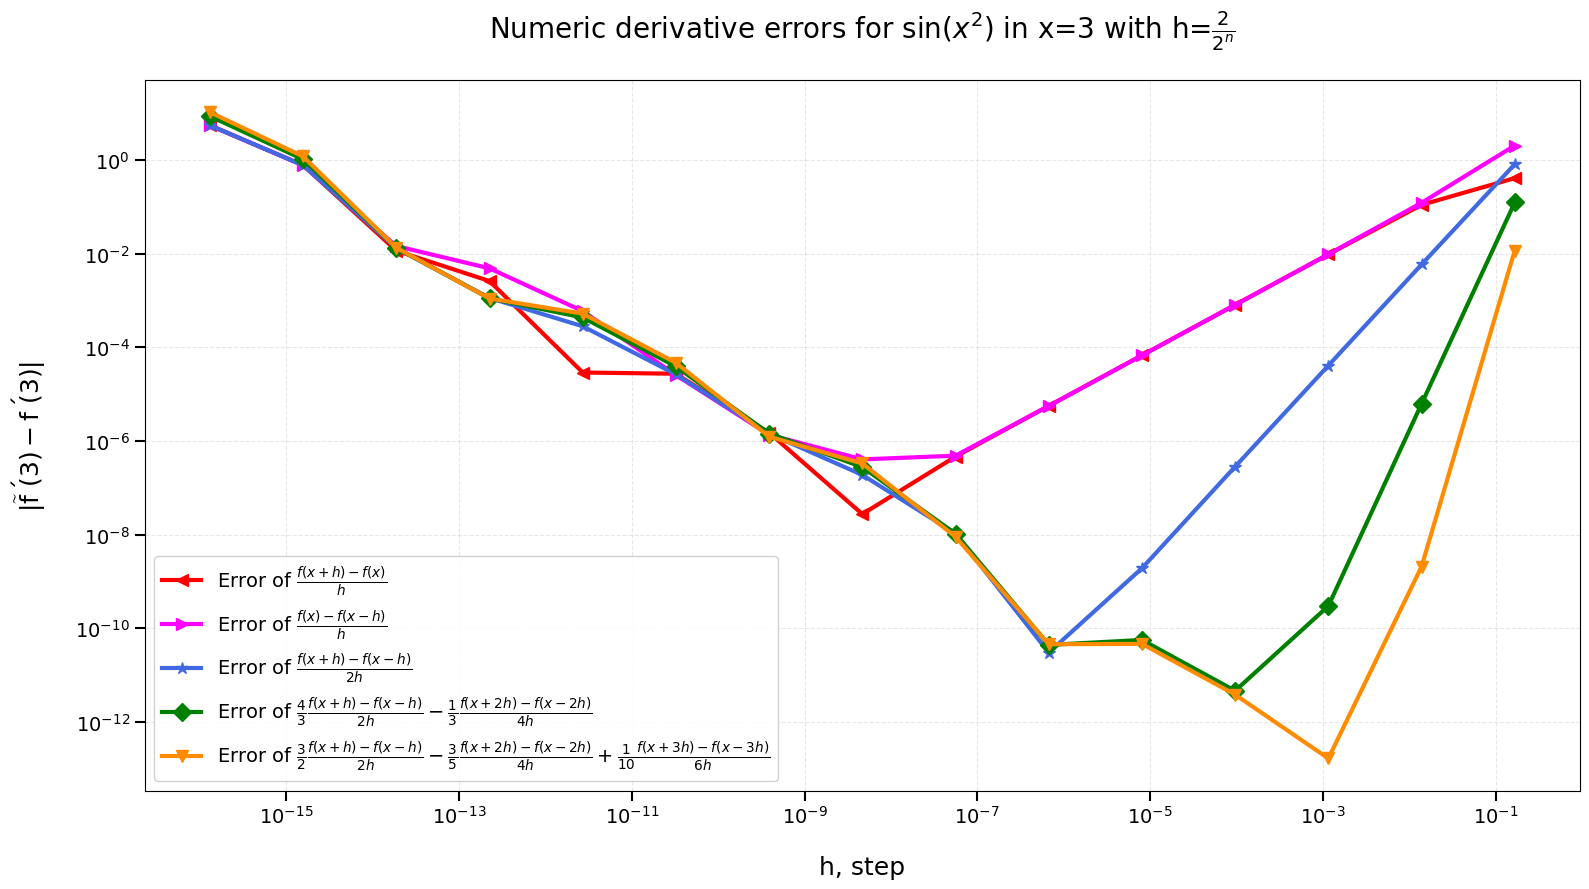

In [11]:
plotter = Plotter(
    title=rf"Numeric derivative errors for ${func_name}$ in x={x_point} with" + f" h=${h_arr_str}$",
    xlabel='h, step',
    ylabel=rf"$\mathrm{{|\widetilde{{f}} \ \'({x_point}) - f \ \'({x_point})|}}$"
)

for key, value in data_to_plot.items():
    plotter.add_plot(h_arr, np.array(value), plot_params[key])

plotter.ax.set_yscale('log')
plotter.ax.set_xscale('log')

plotter.finalize_and_show()

# Run all in cycle

График сохранен в файл: ./graphs/func=1


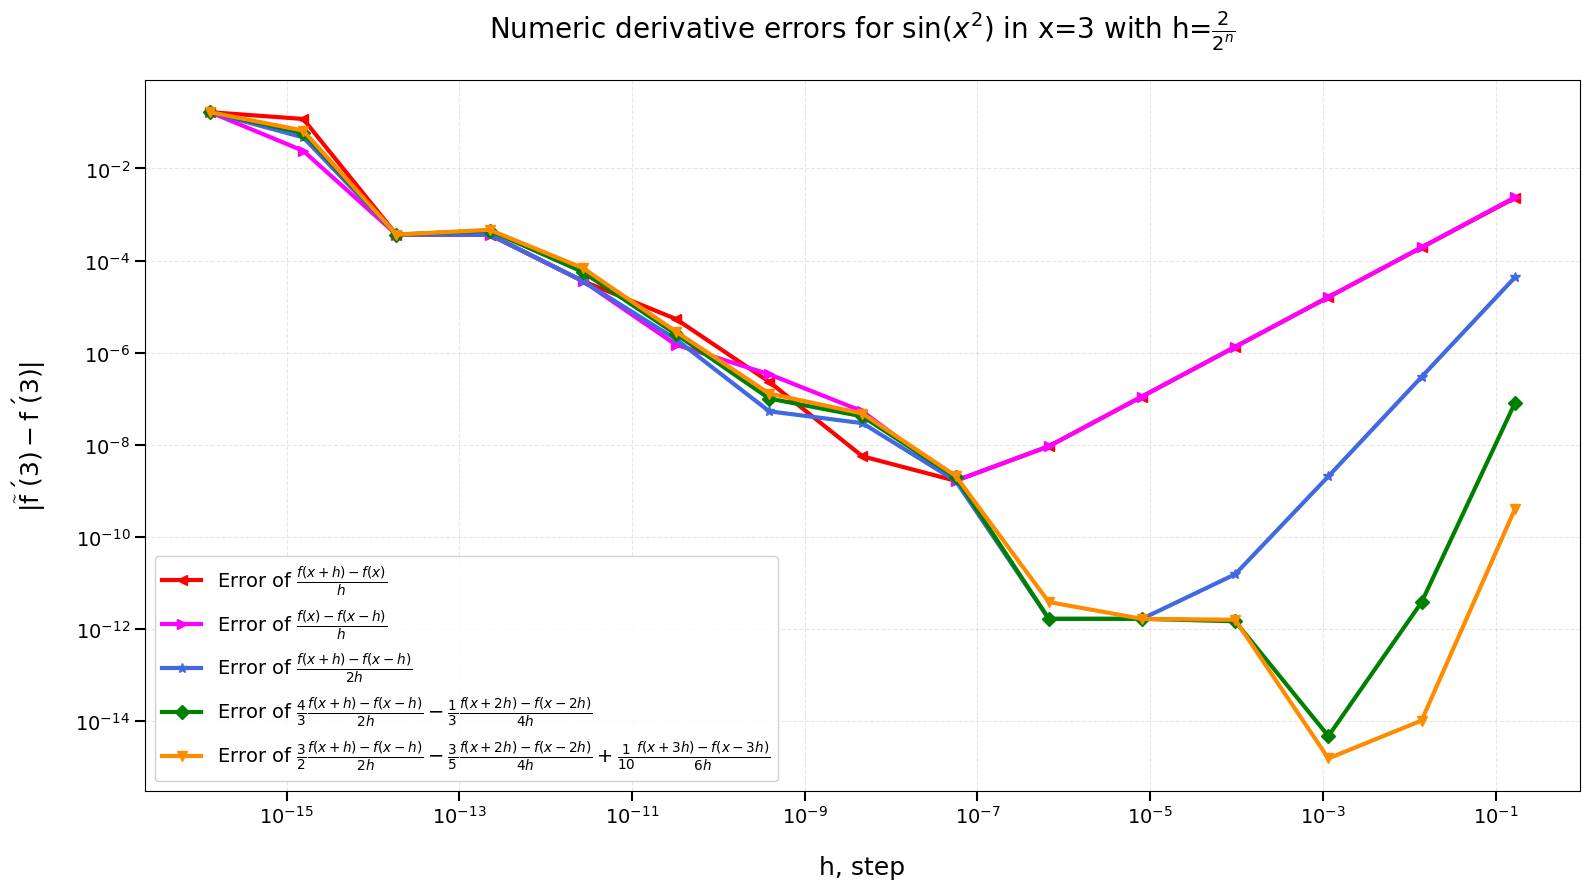

График сохранен в файл: ./graphs/func=2


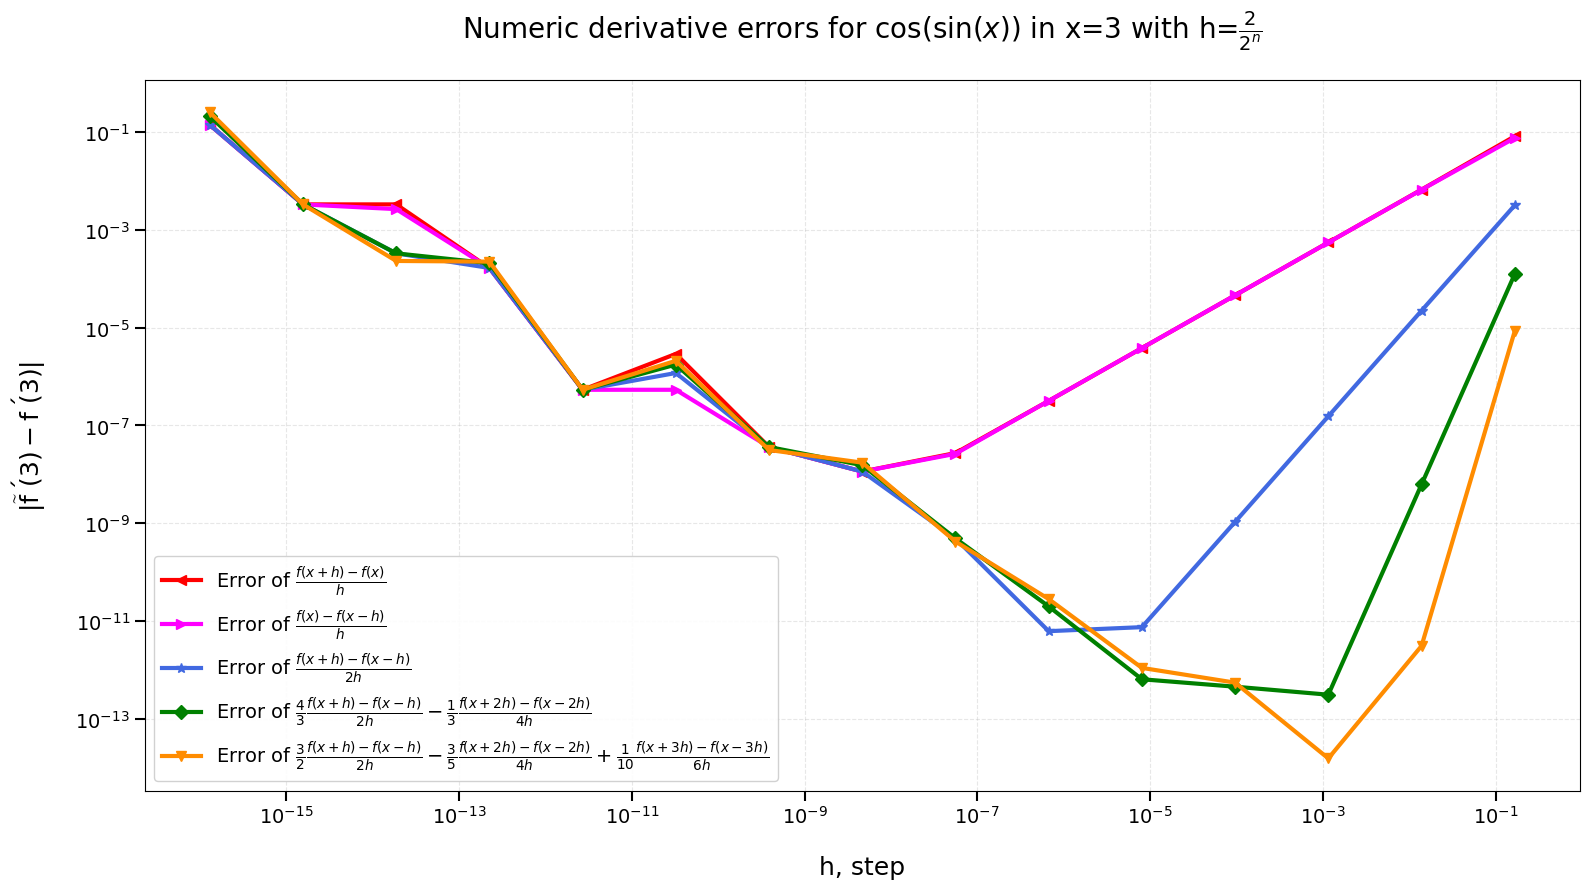

График сохранен в файл: ./graphs/func=3


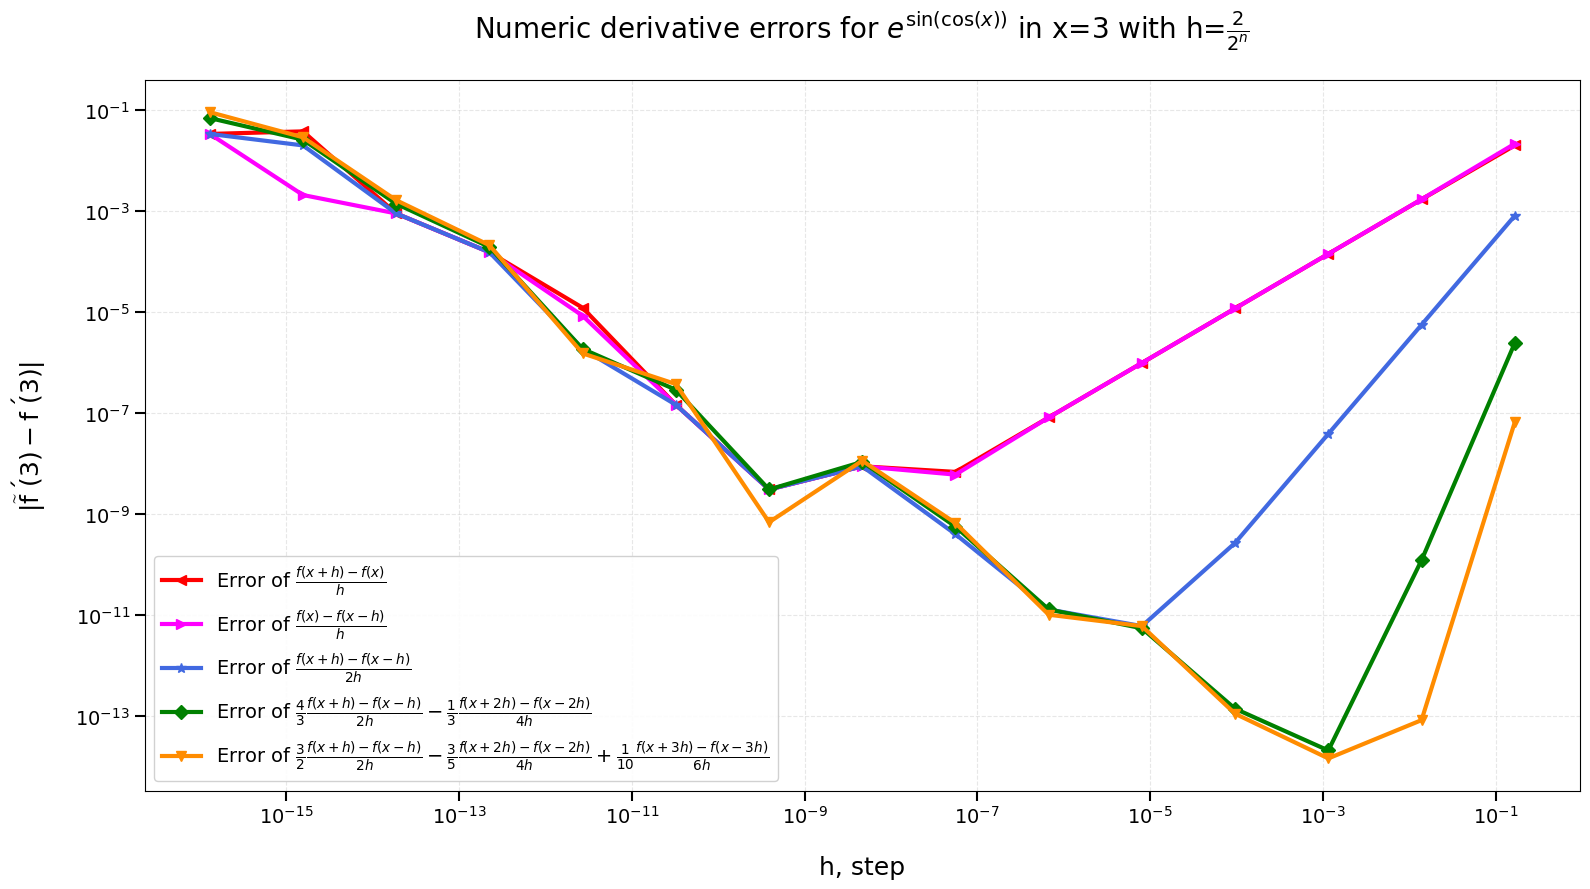

График сохранен в файл: ./graphs/func=4


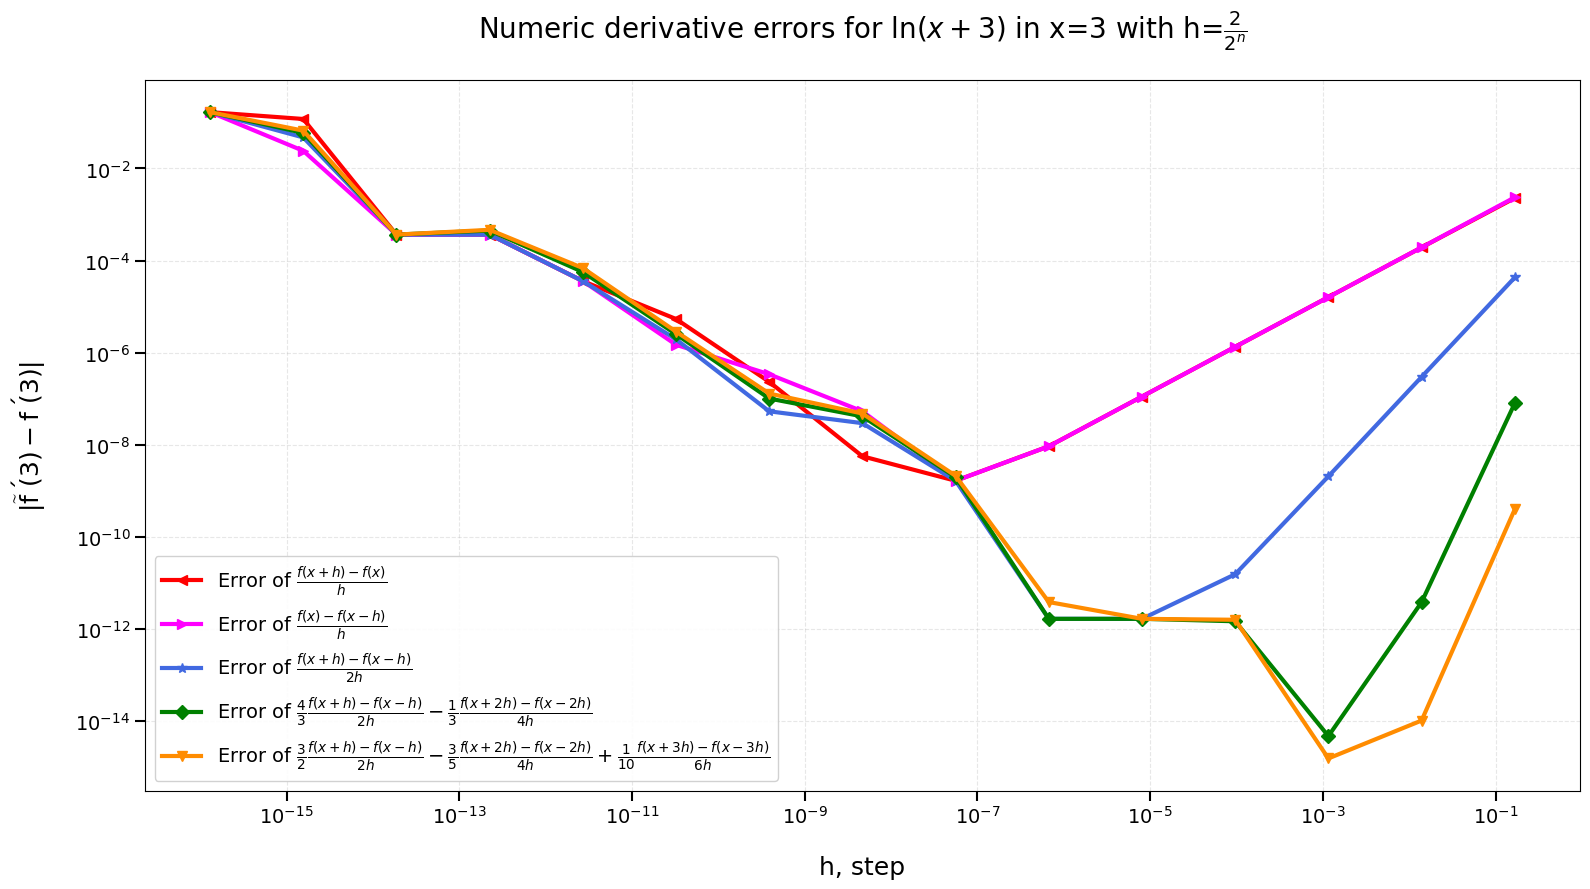

График сохранен в файл: ./graphs/func=5


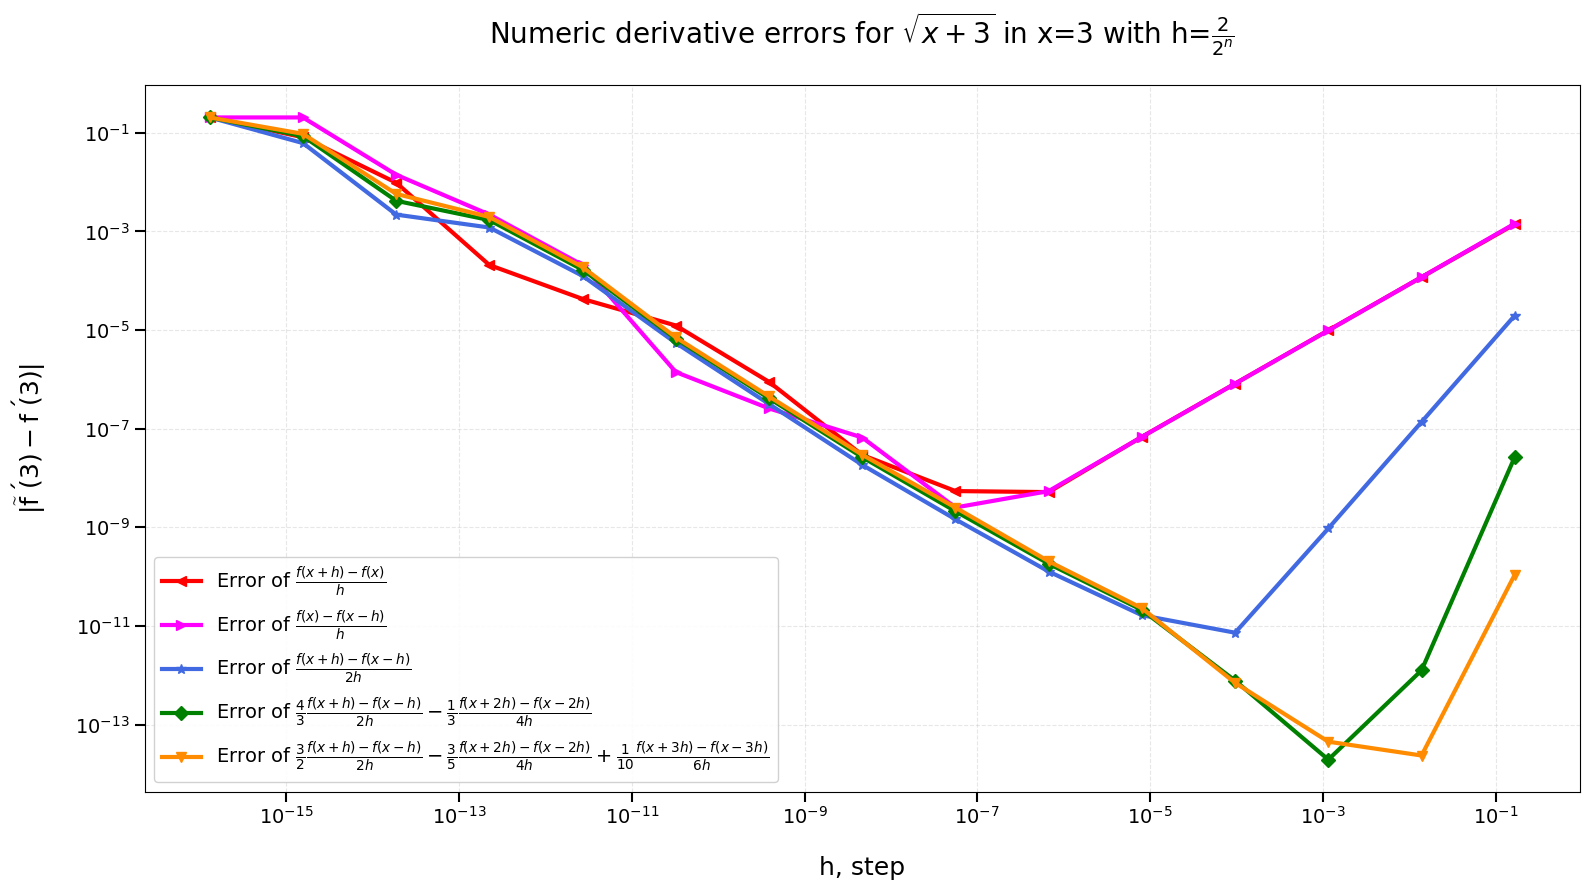

In [12]:
func_to_analyze_tuples_arr = [
    (lambda x: torch.log(x + 3),                   r"\sin(x^2)"),
    (lambda x: torch.cos(torch.sin(x)),            r"\cos(\sin(x))"),
    (lambda x: torch.exp(torch.sin(torch.cos(x))), r"e^{\sin(\cos(x))}" ),
    (lambda x: torch.log(x + 3),                   r"\ln(x + 3)"),
    (lambda x: (x + 3) ** 0.5,                     r"\sqrt{x + 3}")
]

# point where the dirivative is calculated
x_point = 3

h_arr = np.array([2 / (12**n) for n in range(1, 1000)])
h_arr = h_arr[h_arr >= 1e-16]  # deleting too low values
h_arr_str = r'\frac{2}{2^n}'

for func_idx, (func_to_analyze, func_name,) in enumerate(func_to_analyze_tuples_arr):

    # Calculates only one time
    analytical_derivative_value = get_analytical_derivative(func_to_analyze, x_point)

    # Обертка
    numpy_func = lambda x: func_to_analyze(torch.tensor(x, dtype=torch.float64)).item()
    plot_params = {}

    data_to_plot = {
        method_name : [] for method_name in numerical_methods.keys()
    }

    for h_idx, h in enumerate(h_arr):
        for method_name, method_props_dict in numerical_methods.items():

            numeric_derivative = method_props_dict["method"](numpy_func, x_point, h)

            error = abs(numeric_derivative - analytical_derivative_value)
            data_to_plot[method_name].append(error)
    markevery_i = int(len(h_arr) / 10)

    for method_name, method_props_dict in numerical_methods.items():
        plot_params[method_name] = PlotParams(
            linestyle="-",
            color=method_props_dict["color"],
            linewidth=3,
            marker=method_props_dict["marker"],
            markersize=7,
            markevery=markevery_i,
            label=method_props_dict["label"]
        )
    plotter = Plotter(
        title=rf"Numeric derivative errors for ${func_name}$ in x={x_point} with" + f" h=${h_arr_str}$",
        xlabel='h, step',
        ylabel=rf"$\mathrm{{|\widetilde{{f}} \ \'({x_point}) - f \ \'({x_point})|}}$"
    )

    for key, value in data_to_plot.items():
        plotter.add_plot(h_arr, np.array(value), plot_params[key])

    plotter.ax.set_yscale('log')
    plotter.ax.set_xscale('log')

    plotter.finalize_and_show(f'./graphs/func={func_idx + 1}')

In [13]:
import numpy as np
import time

size = 1000
A = np.random.rand(size, size)
B = np.random.rand(size, size)

def python_matmul(A, B):
    C = [[0 for _ in range(size)] for _ in range(size)]
    for i in range(size):
        for j in range(size):
            for k in range(size):
                C[i][j] += A[i][k] * B[k][j]
    return C

# Ручная реализация
start_time = time.time()
C_python = python_matmul(A.tolist(), B.tolist())
end_time = time.time()
print(f"Ручная реализация: {end_time - start_time:.4f} с")


# Numpy (@)
start_time = time.time()
C_numpy = A @ B
end_time = time.time()
print(f"NumPy (@): {end_time - start_time:.4f} с")



Ручная реализация: 100.6399 с
NumPy (@): 0.0173 с
